In [11]:
import requests
import pandas as pd
from dotenv import load_dotenv
import os
import time

load_dotenv()

AV_API_KEY = os.getenv("ALPHA_VANTAGE_API_KEY")

def get_earnings(symbol):
    url = f"https://www.alphavantage.co/query?function=EARNINGS&symbol={symbol}&apikey={AV_API_KEY}"
    r = requests.get(url)
    data = r.json()
    
    if "quarterlyEarnings" not in data:
        print(f"Warning: No earnings data for {symbol}. Response: {data}")
        return pd.DataFrame()
        
    quarterly = pd.DataFrame(data["quarterlyEarnings"])
    quarterly["symbol"] = symbol
    
    # rate limit is 5 per minute
    time.sleep(12.5)
    return quarterly

# example
df_earnings = get_earnings("AAPL")
df_earnings.head()

,fiscalDateEnding,reportedDate,reportedEPS,estimatedEPS,surprise,surprisePercentage,reportTime,symbol
0,2025-12-31,2026-01-29,2.84,2.67,0.17,6.367,post-market,AAPL
1,2025-09-30,2025-10-30,1.85,1.76,0.09,5.1136,post-market,AAPL
2,2025-06-30,2025-07-31,1.57,1.43,0.14,9.7902,post-market,AAPL
3,2025-03-31,2025-05-01,1.65,1.62,0.03,1.8519,post-market,AAPL
4,2024-12-31,2025-01-30,2.4,2.34,0.06,2.5641,post-market,AAPL


In [12]:
df_earnings["reportedDate"] = pd.to_datetime(df_earnings["reportedDate"])
df_earnings["reportedEPS"] = pd.to_numeric(df_earnings["reportedEPS"], errors="coerce")
df_earnings["estimatedEPS"] = pd.to_numeric(df_earnings["estimatedEPS"], errors="coerce")

# compute surprise %
df_earnings["surprise_pct_calc"] = (
    (df_earnings["reportedEPS"] - df_earnings["estimatedEPS"]) /
    df_earnings["estimatedEPS"]
)

df_earnings = df_earnings.dropna()
df_earnings.head()

,fiscalDateEnding,reportedDate,reportedEPS,estimatedEPS,surprise,surprisePercentage,reportTime,symbol,surprise_pct_calc
0,2025-12-31,2026-01-29,2.84,2.67,0.17,6.367,post-market,AAPL,0.063670
1,2025-09-30,2025-10-30,1.85,1.76,0.09,5.1136,post-market,AAPL,0.051136
2,2025-06-30,2025-07-31,1.57,1.43,0.14,9.7902,post-market,AAPL,0.097902
3,2025-03-31,2025-05-01,1.65,1.62,0.03,1.8519,post-market,AAPL,0.018519
4,2024-12-31,2025-01-30,2.40,2.34,0.06,2.5641,post-market,AAPL,0.025641


We also have report timing, which may affect whether returns should be measured same-day or next-day.

In [21]:
import yfinance as yf

def get_prices(symbol):
    df = yf.download(symbol, start="2015-01-01", progress=False)

    # flatten multi-index columns if present
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df.reset_index()
    df["symbol"] = symbol
    return df

df_prices = get_prices("AAPL")
df_prices.head()

Price,Date,Close,High,Low,Open,Volume,symbol
0,2015-01-02,24.214893,24.682226,23.776353,24.671151,212818400,AAPL
1,2015-01-05,23.532724,24.064287,23.346678,23.984553,257142000,AAPL
2,2015-01-06,23.534929,23.794066,23.173909,23.596945,263188400,AAPL
3,2015-01-07,23.864948,23.964616,23.632389,23.743131,160423600,AAPL
4,2015-01-08,24.781897,24.839483,24.075361,24.192749,237458000,AAPL


In [22]:
def compute_returns(prices, earnings):
    prices = prices.copy()
    prices["Date"] = pd.to_datetime(prices["Date"])
    
    results = []

    for _, row in earnings.iterrows():
        date = row["reportedDate"]
        
        # find closest trading day
        closest = prices.iloc[(prices["Date"] - date).abs().argsort()[:1]]
        idx = closest.index[0]
        
        try:
            price_0 = prices.loc[idx, "Close"]
            price_1 = prices.loc[idx + 1, "Close"]
            price_5 = prices.loc[idx + 5, "Close"]

            ret_1d = (price_1 - price_0) / price_0
            ret_5d = (price_5 - price_0) / price_0

            results.append({
                "date": date,
                "symbol": row["symbol"],
                "surprise_pct": row["surprise_pct_calc"],
                "ret_1d": ret_1d,
                "ret_5d": ret_5d
            })

        except:
            continue

    return pd.DataFrame(results)

df_final = compute_returns(df_prices, df_earnings)
df_final.head()

,date,symbol,surprise_pct,ret_1d,ret_5d
0,2026-01-29,AAPL,0.063670,0.004646,0.068259
1,2025-10-30,AAPL,0.051136,-0.003795,-0.006006
2,2025-07-31,AAPL,0.097902,-0.025004,0.060028
3,2025-05-01,AAPL,0.018519,-0.037362,-0.074208
4,2025-01-30,AAPL,0.025641,-0.006692,-0.018393


In [23]:
import yfinance as yf
symbols = ["AAPL", "MSFT", "GOOGL", "AMZN", "META"]
all_data = []

for sym in symbols:
    print(f"Fetching data for {sym}...")
    earnings = get_earnings(sym)
    if earnings.empty:
        continue
        
    # Processing earnings
    earnings["reportedDate"] = pd.to_datetime(earnings["reportedDate"])
    earnings["reportedEPS"] = pd.to_numeric(earnings["reportedEPS"], errors="coerce")
    earnings["estimatedEPS"] = pd.to_numeric(earnings["estimatedEPS"], errors="coerce")
    earnings["surprise_pct_calc"] = (earnings["reportedEPS"] - earnings["estimatedEPS"]) / earnings["estimatedEPS"]
    earnings = earnings.dropna(subset=["reportedDate", "reportedEPS", "estimatedEPS", "surprise_pct_calc"])
    
    prices = get_prices(sym)
    merged = compute_returns(prices, earnings)
    
    # Fetch additional company context via yfinance
    try:
        ticker = yf.Ticker(sym)
        info = ticker.info
        merged["Sector"] = info.get("sector", "Unknown")
        merged["MarketCap"] = info.get("marketCap", pd.NA)
    except:
        merged["Sector"] = "Unknown"
        merged["MarketCap"] = pd.NA
        
    all_data.append(merged)

if all_data:
    df_all = pd.concat(all_data, ignore_index=True)
    display(df_all.head())
else:
    df_all = pd.DataFrame()
    print("No data gathered.")

Fetching data for AAPL...
Fetching data for MSFT...
Fetching data for GOOGL...
Fetching data for AMZN...
Fetching data for META...


,date,symbol,surprise_pct,ret_1d,ret_5d,Sector,MarketCap
0,2026-01-29,AAPL,0.063670,0.004646,0.068259,Technology,3767813275648
1,2025-10-30,AAPL,0.051136,-0.003795,-0.006006,Technology,3767813275648
2,2025-07-31,AAPL,0.097902,-0.025004,0.060028,Technology,3767813275648
3,2025-05-01,AAPL,0.018519,-0.037362,-0.074208,Technology,3767813275648
4,2025-01-30,AAPL,0.025641,-0.006692,-0.018393,Technology,3767813275648


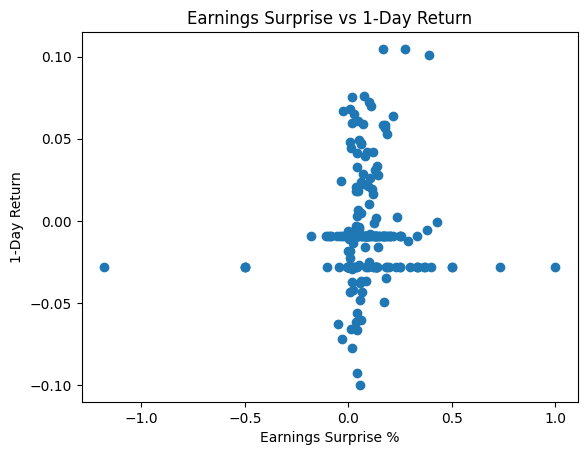

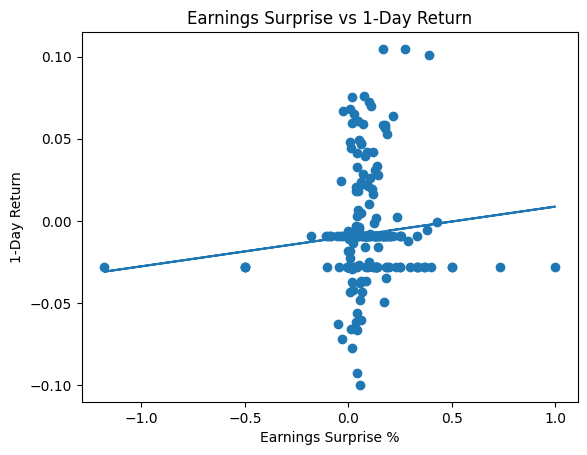

In [28]:
import matplotlib.pyplot as plt
import numpy as np

plt.scatter(df_all["surprise_pct"], df_all["ret_1d"])
plt.xlabel("Earnings Surprise %")
plt.ylabel("1-Day Return")
plt.title("Earnings Surprise vs 1-Day Return")
plt.show()

x = df_all["surprise_pct"]
y = df_all["ret_1d"]

m, b = np.polyfit(x, y, 1)
plt.scatter(x, y)
plt.plot(x, m*x + b)

plt.xlabel("Earnings Surprise %")
plt.ylabel("1-Day Return")
plt.title("Earnings Surprise vs 1-Day Return")
plt.show()

In [29]:
df_all[["surprise_pct", "ret_1d", "ret_5d"]].corr()

,surprise_pct,ret_1d,ret_5d
surprise_pct,1.000000,0.094368,0.083603
ret_1d,0.094368,1.000000,0.685652
ret_5d,0.083603,0.685652,1.000000


small but positive relationship, .09 means there might be a real effect but we need to do better modeling. maybe not strictly linear or have more features like extreme surpirses or firm characteristics.

In [32]:
import statsmodels.api as sm

X = df_all["surprise_pct"]
y = df_all["ret_1d"]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

X = df_all[["surprise_pct", "MarketCap"]].dropna()
y = df_all.loc[X.index, "ret_1d"]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 ret_1d   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     2.049
Date:                Thu, 26 Mar 2026   Prob (F-statistic):              0.154
Time:                        09:52:57   Log-Likelihood:                 464.04
No. Observations:                 230   AIC:                            -924.1
Df Residuals:                     228   BIC:                            -917.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.0095      0.002     -4.045   